# Functions of QAOA angles

In this How-To we optimize QAOA angles in a different basis. We consider the Fourier bases as done by Zhou et al. in PRX 10, 021067 (2020). The optimization is carried out at small scale with a state vector simulator.

In [17]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from qiskit import transpile
from qiskit.circuit.library import QAOAAnsatz

from qiskit_ibm_runtime import Sampler

from qiskit_aer import AerSimulator

from qaoa_training_pipeline.evaluation import StatevectorEvaluator
from qaoa_training_pipeline.training.functions import FourierFunction
from qaoa_training_pipeline.training.parameter_extenders import trivial_extend
from qaoa_training_pipeline.training import DepthOneScanTrainer, ScipyTrainer, RecursionTrainer
from qaoa_training_pipeline.utils.graph_utils import load_graph, graph_to_operator

In [18]:
graph = load_graph("../data/problems/example_graph.json")
cost_op = graph_to_operator(graph, pre_factor=-0.5)

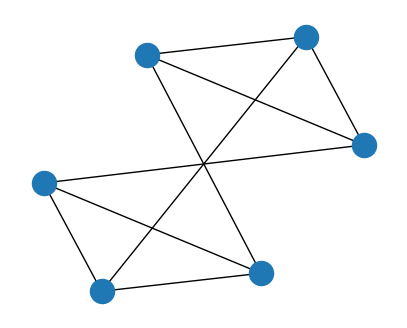

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
nx.draw_kamada_kawai(graph, ax=ax)

## 1) Vanilla optimization from a random initial point

Here, we optimize the Fourier coefficients for a depth-10 QAOA starting from a random initial point. The QAOA depth is fixed by the function `FourierFunction(depth=10)`. The number of Fourier coefficients is fixed by the initial point. In this case we have four coefficients for $\gamma$ and four coefficients for $\beta$.

In [20]:
trainer = ScipyTrainer(
    StatevectorEvaluator(),
    minimize_args={"options": {"maxiter": 500}},
    qaoa_angles_function=FourierFunction(depth=10),
)

In [21]:
result = trainer.provide_params(cost_op, params0=np.random.uniform(0, np.pi, 8).tolist())

The `qaoa_angles_function` in the trainer lets us plot both the QAOA angles as well as the function in the Fourier basis.

(<Figure size 1400x400 with 3 Axes>,
 <Axes: xlabel='Iteration number', ylabel='Energy'>)

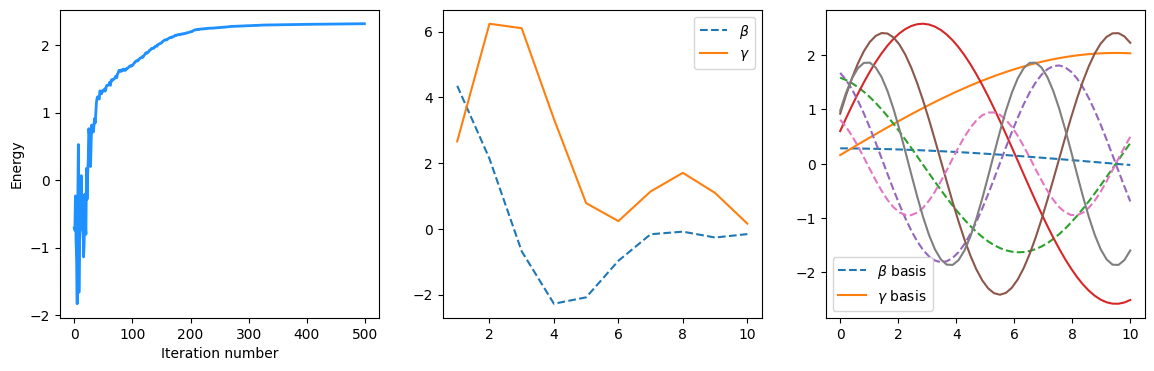

In [22]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
assert isinstance(trainer.qaoa_angles_function, FourierFunction)
trainer.qaoa_angles_function.plot_angles(result["parameter_history"][-1], axs[1])
trainer.qaoa_angles_function.plot_basis(result["parameter_history"][-1], axs[2])
trainer.plot(axis=axs[0], fig=fig)

In [23]:
print(result["optimized_qaoa_angles"])

[4.35072647432787, 2.1344042636721636, -0.6832538238484414, -2.279326362227473, -2.085095857164143, -0.9728799494771972, -0.16495912545030145, -0.08612671160427865, -0.2650309140061985, -0.16110037556932122, 2.6608844942476453, 6.240245971960361, 6.102886364000282, 3.341750915567255, 0.7807792820367758, 0.23441613401528633, 1.1370643024795077, 1.703547633745766, 1.0916447518803625, 0.15775974872250687]


In [24]:
print(result["optimized_params"])

[0.2854082400316067, 1.6287245266540893, 1.8106237390872886, 0.9496117290102972, 2.0389046164546536, 2.577134672894352, 2.409277672368478, 1.870441676130825]


## 2) Recursive optimization

In the following we recursively optimize the coefficients of the Fourier representation of the QAOA parameters. The underlying is a depth-ten 10 as indicated by
```python
FourierFunction(depth=10)
```
The recursive trainer will start from an initial point found via a depth-one scan in the Fourier basis. This will produce a good initial point $(u^\star_1, v^\star_1)$ with which to seed the recursion. The initial points at depth $p+1$ are trvially found from depth $p$ by extending the parameter vector with zeros. This is done by the `trivial_extend` function. It corresponds to extending the Fourier basis by one mode, initially set to amplitude zero.

In [25]:
angles_func = FourierFunction(depth=10)

pre_trainer = DepthOneScanTrainer(
    StatevectorEvaluator(),
    qaoa_angles_function=angles_func,
    parameter_ranges=[(0, np.pi), (0, np.pi)],
)

sub_trainer = ScipyTrainer(
    StatevectorEvaluator(),
    minimize_args={"options": {"maxiter": 500, "rhobeg": 0.2}},
    qaoa_angles_function=angles_func,
)

rtrainer = RecursionTrainer(trainer=sub_trainer, parameter_extender=trivial_extend, reps=6)

In [26]:
presult = pre_trainer.provide_params(cost_op)

In [27]:
rresult = rtrainer.provide_params(cost_op, params0=presult["optimized_params"])

We also prepare an optimize QAOA circuit and sample from it to show that we indeed get good samples. The optimal QAOA angles are found in `rresult["optimized_qaoa_angles"]`. Below, we observe that each level of the recusion increases the energy which is a sign of a good optimization.

In [28]:
optimal_circuit = QAOAAnsatz(cost_op, reps=len(rresult["optimized_qaoa_angles"]) // 2).decompose()
optimal_circuit.assign_parameters(rresult["optimized_qaoa_angles"], inplace=True)
optimal_circuit.measure_all()

sampler = Sampler(mode=AerSimulator())
isa_circuit = transpile(optimal_circuit, basis_gates=["sx", "x", "rzz", "rz"])
sampler_result = sampler.run([isa_circuit]).result()[0].data.meas.get_counts()

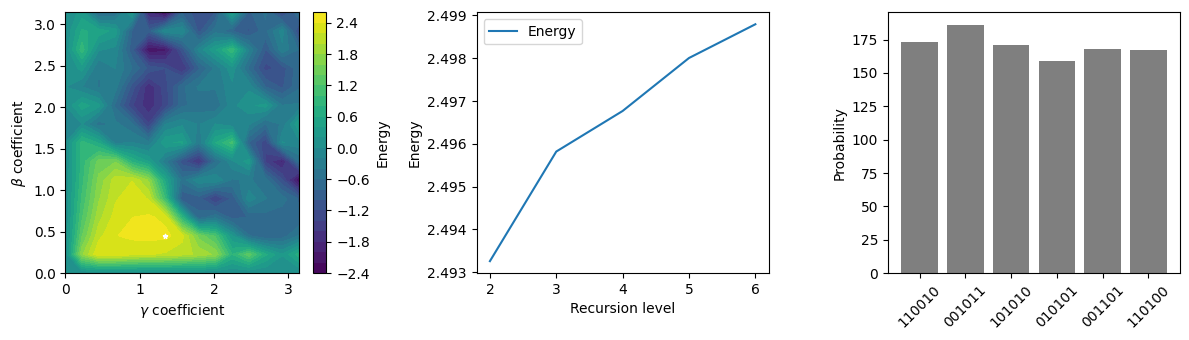

In [29]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3.5))
pre_trainer.plot(
    fig=fig, axis=axs[0], xlabel=r"$\gamma$ coefficient", ylabel=r"$\beta$ coefficient"
)
rtrainer.plot(fig=fig, axis=axs[1])
axs[2].bar(list(sampler_result.keys()), list(sampler_result.values()), color="tab:grey")
axs[2].set_ylabel("Probability")
plt.xticks(rotation=45)
plt.tight_layout()